In [6]:
#!pip install pandas 
#!pip install openpyxl 

In [7]:
import pandas as pd

In [8]:
DATA_PATH = "Notebooks/Inputs/Hospitales.xlsx"

# Se abre el libro una sola vez para leer la base principal y los catalogos.
# Mantener los catalogos separados permite usarlos para interpretar codigos
# sin incorporarlos automaticamente como predictores del modelo.
with pd.ExcelFile(DATA_PATH) as xls:
    df = pd.read_excel(xls, sheet_name="Base de datos")
    estatus = pd.read_excel(xls, sheet_name="Estatus")
    ciudades = pd.read_excel(xls, sheet_name="Ciudades")
    enfermedades = pd.read_excel(xls, sheet_name="Enfermedades")
    gravedad = pd.read_excel(xls, sheet_name="Gravedad")


In [9]:
df["EDAD_CUADRADO"] = df["EDAD"] ** 2


In [10]:
df["GRUPO_ETARIO"] = pd.cut(
    df["EDAD"], 
    bins=[-1, 12, 29, 59, 74, 120], 
    labels=["Pediatrico", "Joven", "Adulto", "Adulto_Mayor", "Geriatrico"]
)


In [11]:
df

,ID,DIAS_ESTANCIA,EDAD,GENERO,PESO,ALTURA,IMC,MES,ENTIDAD,INDIGENA,MOTIVO_EGRESO,CODIGO_ENFERMEDAD,EDAD_CUADRADO,GRUPO_ETARIO
0,2738822,1,23,2,63,147.0,29.154519,2,29,2,1,O809,529,Joven
1,2735411,2,22,2,84,NaN,NaN,6,8,2,1,O829,484,Joven
2,2731022,2,23,2,86,151.0,37.717644,2,4,2,1,O809,529,Joven
3,2726593,0,67,2,45,152.0,19.477147,3,20,2,1,H259,4489,Adulto_Mayor
4,2723606,2,27,2,53,154.0,22.347782,2,21,2,1,O064,729,Joven
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29889,625419,0,28,1,70,160.0,27.343750,8,15,2,9,N189,784,Joven
29890,616410,0,51,2,70,160.0,27.343750,8,15,2,9,N189,2601,Adulto
29891,356322,3,41,2,50,140.0,25.510204,12,9,2,9,D259,1681,Adulto
29892,356309,3,27,2,88,154.0,37.105751,12,9,2,9,O829,729,Joven


In [12]:
# Unión de la base principal con el catálogo de enfermedades.
# Se conserva cada registro de df y se agregan sus descripciones y nivel de gravedad.
Columnas_deseadas = [
    "CODIGO_ENFERMEDAD",
    "CODIGO_ENFERMEDAD_DESC",
    "Tipo de Problema",
    "Nivel de gravedad",
]



In [13]:

# El catálogo debe tener un solo registro por código para no duplicar pacientes.
disease_catalog = enfermedades[Columnas_deseadas].drop_duplicates("CODIGO_ENFERMEDAD")
df = df.merge(disease_catalog, on="CODIGO_ENFERMEDAD", how="left", validate="many_to_one")
df = df.rename(columns={
    "Nivel de gravedad": "NIVEL_DE_GRAVEDAD",
    "Tipo de Problema": "TIPO_DE_PROBLEMA_MEDICO",
})

# Nombre solicitado para la variable indígena.
if "INDIGENA" in df.columns and "ES_INDIGENA" not in df.columns:
    df["ES_INDIGENA"] = df["INDIGENA"]

print(f"Filas después de la unión: {len(df):,}")
print(f"Códigos sin correspondencia: {df['CODIGO_ENFERMEDAD_DESC'].isna().sum():,}")
df.head(5)

Filas después de la unión: 29,894
Códigos sin correspondencia: 0


,ID,DIAS_ESTANCIA,EDAD,GENERO,PESO,ALTURA,IMC,MES,ENTIDAD,INDIGENA,MOTIVO_EGRESO,CODIGO_ENFERMEDAD,EDAD_CUADRADO,GRUPO_ETARIO,CODIGO_ENFERMEDAD_DESC,TIPO_DE_PROBLEMA_MEDICO,NIVEL_DE_GRAVEDAD,ES_INDIGENA
0,2738822,1,23,2,63,147.0,29.154519,2,29,2,1,O809,529,Joven,"Parto único espontáneo, sin otra especificación","Embarazo, parto y puerperio",3.0,2
1,2735411,2,22,2,84,NaN,NaN,6,8,2,1,O829,484,Joven,"Parto por cesárea, sin otra especificación","Embarazo, parto y puerperio",3.0,2
2,2731022,2,23,2,86,151.0,37.717644,2,4,2,1,O809,529,Joven,"Parto único espontáneo, sin otra especificación","Embarazo, parto y puerperio",3.0,2
3,2726593,0,67,2,45,152.0,19.477147,3,20,2,1,H259,4489,Adulto_Mayor,"Catarata senil, no especificada",Enfermedades del ojo y sus anexos,1.0,2
4,2723606,2,27,2,53,154.0,22.347782,2,21,2,1,O064,729,Joven,"Aborto no especificado incompleto, sin complic...","Embarazo, parto y puerperio",3.0,2


## Modelo para predecir egreso por mejora

El flujo siguiente parte de `df` y se organiza en cinco etapas: análisis exploratorio, limpieza y preparación, ingeniería de variables, entrenamiento/evaluación y guardado de artefactos. Ajusta `columna_objetivo` al nombre exacto de la variable que indica el motivo o tipo de egreso.

### Descripcion del flujo

Este notebook documenta y ejecuta el ciclo completo de modelado. Cada etapa deja variables intermedias y resultados que permiten auditar el proceso antes de utilizar el modelo en produccion.

**1. Lectura de datos.** Se carga la hoja `Base de datos` como fuente de pacientes y se conservan por separado los catalogos `Estatus`, `Ciudades`, `Enfermedades` y `Gravedad`. La base contiene identificadores y mediciones; los catalogos permiten convertir codigos en informacion interpretable.

**2. Ingenieria inicial.** Se crean `EDAD_CUADRADO` y `GRUPO_ETARIO` para evaluar si una relacion no lineal o una agrupacion clinica mejora a la edad original. Estas variantes se comparan experimentalmente y no se incorporan al modelo final si no aportan evidencia.

**3. Uso de catalogos.** El catalogo `Estatus` define de forma reproducible la clase positiva. `Enfermedades` agrega descripcion, tipo de problema y nivel de gravedad. `Ciudades` agrega el nombre de la entidad. Las uniones son de tipo izquierdo y validan relaciones muchos-a-uno para evitar duplicar pacientes.

**4. Analisis exploratorio.** Se revisan tipos, nulos, cardinalidad, distribucion del objetivo, estadistica descriptiva y correlaciones. Esto identifica problemas de calidad y evita interpretar accuracy como unica medida cuando existe desbalance de clases.

**5. Limpieza y preparacion.** Se separan predictores y objetivo. La imputacion y el escalamiento se ajustan dentro de un `Pipeline`, usando solamente el conjunto de entrenamiento en cada validacion. Las variables categoricas se transforman con one-hot encoding y las desconocidas se ignoran.

**6. Entrenamiento y comparacion.** Se comparan baseline, regresion logistica, Random Forest y SVM lineal calibrada. La division de prueba es estratificada y la seleccion inicial usa validacion cruzada ROC-AUC.

**7. Control de overfitting.** El Random Forest se regulariza con profundidad maxima, hojas minimas y numero de variables por division. La seleccion final penaliza la brecha entre ROC-AUC de entrenamiento y validacion, buscando generalizacion y no solamente ajuste.

**8. Evaluacion y persistencia.** Se revisan ROC-AUC, F1, precision, recall, accuracy, Brier score, average precision, curvas de aprendizaje e importancia por permutacion. Finalmente se guardan datos, reportes, metadatos y el pipeline `joblib` reutilizable.


In [14]:
#!pip install matplotlib seaborn  

In [15]:
from pathlib import Path
import json
import sys
import subprocess

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Como el notebook vive en la raiz, los reportes permanecen dentro de Notebooks/Outputs.
# Esta carpeta concentra los resultados estadisticos y evita mezclarlos con los scripts.
OUTPUT_DIR = Path("Notebooks/Outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [16]:

# El objetivo se construye desde MOTIVO_EGRESO y el catálogo estatus.
columna_objetivo = "EGRESO_MEJORIA"
columna_de_estatus = "MOTIVO_EGRESO"
semilla = 42


In [17]:
df.head(2)

,ID,DIAS_ESTANCIA,EDAD,GENERO,PESO,ALTURA,IMC,MES,ENTIDAD,INDIGENA,MOTIVO_EGRESO,CODIGO_ENFERMEDAD,EDAD_CUADRADO,GRUPO_ETARIO,CODIGO_ENFERMEDAD_DESC,TIPO_DE_PROBLEMA_MEDICO,NIVEL_DE_GRAVEDAD,ES_INDIGENA
0,2738822,1,23,2,63,147.0,29.154519,2,29,2,1,O809,529,Joven,"Parto único espontáneo, sin otra especificación","Embarazo, parto y puerperio",3.0,2
1,2735411,2,22,2,84,NaN,NaN,6,8,2,1,O829,484,Joven,"Parto por cesárea, sin otra especificación","Embarazo, parto y puerperio",3.0,2


In [18]:

fila_mejoria = estatus[
    estatus["MOTIVO_EGRESO_DESC"].
    astype("string").
    str.strip().str.lower().
    str.contains("mejoría", na=False)
]


In [19]:
fila_mejoria

,MOTIVO_EGRESO,MOTIVO_EGRESO_DESC
1,2,mejoría


In [20]:

Codigo_mejoria = fila_mejoria["MOTIVO_EGRESO"].iloc[0]
print(Codigo_mejoria)

2


In [21]:

df = df.copy()
df[columna_objetivo] = (
    df[columna_de_estatus].
    astype("string").str.strip() == str(Codigo_mejoria).strip()
).astype("int8")



In [22]:
df.head(5)

,ID,DIAS_ESTANCIA,EDAD,GENERO,PESO,ALTURA,IMC,MES,ENTIDAD,INDIGENA,MOTIVO_EGRESO,CODIGO_ENFERMEDAD,EDAD_CUADRADO,GRUPO_ETARIO,CODIGO_ENFERMEDAD_DESC,TIPO_DE_PROBLEMA_MEDICO,NIVEL_DE_GRAVEDAD,ES_INDIGENA,EGRESO_MEJORIA
0,2738822,1,23,2,63,147.0,29.154519,2,29,2,1,O809,529,Joven,"Parto único espontáneo, sin otra especificación","Embarazo, parto y puerperio",3.0,2,0
1,2735411,2,22,2,84,NaN,NaN,6,8,2,1,O829,484,Joven,"Parto por cesárea, sin otra especificación","Embarazo, parto y puerperio",3.0,2,0
2,2731022,2,23,2,86,151.0,37.717644,2,4,2,1,O809,529,Joven,"Parto único espontáneo, sin otra especificación","Embarazo, parto y puerperio",3.0,2,0
3,2726593,0,67,2,45,152.0,19.477147,3,20,2,1,H259,4489,Adulto_Mayor,"Catarata senil, no especificada",Enfermedades del ojo y sus anexos,1.0,2,0
4,2723606,2,27,2,53,154.0,22.347782,2,21,2,1,O064,729,Joven,"Aborto no especificado incompleto, sin complic...","Embarazo, parto y puerperio",3.0,2,0


### Paso 0. Definicion del problema y construccion de la respuesta

El objetivo operativo es estimar, antes del egreso, si el paciente terminara su atencion por mejoria. La base contiene `MOTIVO_EGRESO` como codigo, pero el significado de cada codigo esta en el catalogo `Estatus`.

La fila cuyo texto contiene la palabra `mejor` se localiza automaticamente. Su codigo se guarda en `Codigo_mejoria` y se compara contra cada registro de la base para crear `EGRESO_MEJORIA`: `1` significa egreso por mejoria y `0` cualquier otro motivo.

Esta definicion evita escribir manualmente el codigo y hace que el proceso pueda repetirse con otro archivo que conserve la misma estructura. La columna `MOTIVO_EGRESO` no se usa como predictor porque contiene directamente la respuesta; incluirla produciria fuga de informacion y metricas artificialmente altas.


In [23]:
# 1. Análisis exploratorio.

descriptiva = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(dropna=False),
}).sort_values("porcentaje_nulos", ascending=False)
display(descriptiva)



,tipo,nulos,porcentaje_nulos,valores_unicos
ALTURA,float64,2894,9.68,171
IMC,float64,2894,9.68,3455
ID,int64,0,0.00,29894
CODIGO_ENFERMEDAD,object,0,0.00,2289
ES_INDIGENA,int64,0,0.00,3
NIVEL_DE_GRAVEDAD,float64,0,0.00,5
TIPO_DE_PROBLEMA_MEDICO,str,0,0.00,20
CODIGO_ENFERMEDAD_DESC,str,0,0.00,2288
GRUPO_ETARIO,category,0,0.00,5
EDAD_CUADRADO,int64,0,0.00,106


In [24]:


display(df[columna_objetivo].value_counts(dropna=False).to_frame("frecuencia"))


,frecuencia
EGRESO_MEJORIA,
1,26793
0,3101


In [25]:

numericos = df.select_dtypes(include=np.number).columns
numericos

Index(['ID', 'DIAS_ESTANCIA', 'EDAD', 'GENERO', 'PESO', 'ALTURA', 'IMC', 'MES',
       'ENTIDAD', 'INDIGENA', 'MOTIVO_EGRESO', 'EDAD_CUADRADO',
       'NIVEL_DE_GRAVEDAD', 'ES_INDIGENA', 'EGRESO_MEJORIA'],
      dtype='str')

,count,mean,std,min,25%,50%,75%,max
ID,29894.0,1.386541e+06,839131.153638,36.0,597433.000000,1.387373e+06,2.164698e+06,2.739028e+06
DIAS_ESTANCIA,29894.0,3.356894e+00,9.864152,0.0,1.000000,1.000000e+00,3.000000e+00,5.500000e+02
EDAD,29894.0,3.118171e+01,19.768426,1.0,19.000000,2.600000e+01,4.100000e+01,1.180000e+02
GENERO,29894.0,1.722319e+00,0.447863,1.0,1.000000,2.000000e+00,2.000000e+00,2.000000e+00
PESO,29894.0,6.093316e+01,23.678744,1.0,54.000000,6.500000e+01,7.500000e+01,2.460000e+02
ALTURA,27000.0,1.476258e+02,29.536231,30.0,149.000000,1.560000e+02,1.620000e+02,2.140000e+02
IMC,27000.0,2.618093e+01,10.348642,1.0,22.222222,2.572103e+01,2.938476e+01,4.162331e+02
MES,29894.0,6.510771e+00,3.405058,1.0,4.000000,7.000000e+00,9.000000e+00,1.200000e+01
ENTIDAD,29894.0,1.648739e+01,7.589933,1.0,11.000000,1.500000e+01,2.100000e+01,3.200000e+01
INDIGENA,29894.0,2.079715e+00,0.880720,1.0,2.000000,2.000000e+00,2.000000e+00,9.000000e+00


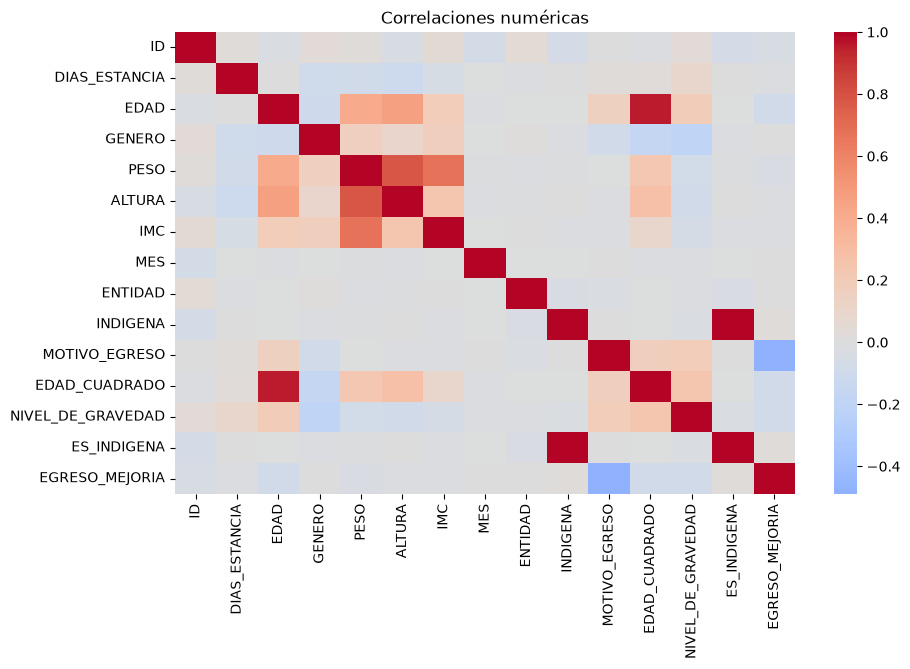

In [26]:

if len(numericos) > 1:
    display(df[numericos].describe().T)
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[numericos].corr(), cmap="coolwarm", center=0)
    plt.title("Correlaciones numéricas")
    plt.show()

### Paso 1. Analisis exploratorio de datos

El analisis exploratorio establece una linea base de calidad antes de entrenar. La tabla descriptiva informa el tipo de dato, cantidad y porcentaje de nulos y numero de valores distintos por columna.

La distribucion de `EGRESO_MEJORIA` permite conocer el desbalance entre pacientes que egresaron por mejoria y pacientes con otros motivos. Por ello se reportan ROC-AUC, F1, precision y recall, ademas de accuracy.

La estadistica descriptiva resume escala, dispersion y posibles valores extremos de las variables numericas. La matriz de correlacion sirve como inspeccion inicial de relaciones lineales, pero no decide por si sola que variables conservar.

Este bloque tambien permite identificar columnas que requeriran imputacion, variables casi constantes y posibles inconsistencias antes de construir el pipeline de entrenamiento.


In [27]:
df_filtrado = df[df['EGRESO_MEJORIA'] == 1]
df_filtrado.head(5)

,ID,DIAS_ESTANCIA,EDAD,GENERO,PESO,ALTURA,IMC,MES,ENTIDAD,INDIGENA,MOTIVO_EGRESO,CODIGO_ENFERMEDAD,EDAD_CUADRADO,GRUPO_ETARIO,CODIGO_ENFERMEDAD_DESC,TIPO_DE_PROBLEMA_MEDICO,NIVEL_DE_GRAVEDAD,ES_INDIGENA,EGRESO_MEJORIA
1285,2739028,1,25,2,72,158.0,28.841532,1,29,2,2,O809,625,Joven,"Parto único espontáneo, sin otra especificación","Embarazo, parto y puerperio",3.0,2,1
1286,2738925,2,22,2,85,153.0,36.310821,2,29,2,2,O339,484,Joven,Atención materna por desproporción de origen n...,"Embarazo, parto y puerperio",3.0,2,1
1287,2738606,1,4,1,20,120.0,13.888889,2,29,2,2,S069,16,Pediatrico,"Traumatismo intracraneal, no especificado","Traumatismos, envenenamientos y algunas otras ...",4.0,2,1
1288,2738583,1,21,2,69,156.0,28.353057,1,29,2,2,O809,441,Joven,"Parto único espontáneo, sin otra especificación","Embarazo, parto y puerperio",3.0,2,1
1289,2738513,2,35,2,52,156.0,21.367521,2,29,2,2,K801,1225,Adulto,Cálculo de la vesícula biliar con otra colecis...,Enfermedades del aparato digestivo,4.0,2,1


In [28]:
#!pip install scikit-learn joblib

In [29]:
# 2. Limpieza y preparación de las variables explicativas.
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
import joblib


In [30]:
work = df.copy()
work.columns = [str(column).strip() for column in work.columns]
work["EDAD"] = pd.to_numeric(work["EDAD"], errors="coerce")
work["EDAD_CUADRADO"] = work["EDAD"] ** 2
work["GRUPO_ETARIO"] = pd.cut(
    work["EDAD"],
    bins=[-np.inf, 17, 29, 44, 59, np.inf],
    labels=["0-17", "18-29", "30-44", "45-59", "60+"],
    include_lowest=True,
)
y = work[columna_objetivo].astype("int8")


In [31]:
columnas_modelo = [
    "DIAS_ESTANCIA", "EDAD", "EDAD_CUADRADO", "GRUPO_ETARIO", "GENERO",
    "NIVEL_DE_GRAVEDAD", "IMC", "ES_INDIGENA", "ENTIDAD", "MES",
]

columnas_comunes_edad = [
    "DIAS_ESTANCIA", "GENERO", "NIVEL_DE_GRAVEDAD", "IMC",
    "ES_INDIGENA", "ENTIDAD", "MES",
]


In [32]:
escenarios = {
    "base_8_variables": columnas_comunes_edad + ["EDAD"],
    "base_mas_codigo_enfermedad": columnas_comunes_edad + ["EDAD", "CODIGO_ENFERMEDAD"],
    "base_mas_tipo_problema": columnas_comunes_edad + ["EDAD", "TIPO_DE_PROBLEMA_MEDICO"],
    "base_mas_codigo_y_tipo": columnas_comunes_edad + [
        "EDAD", "CODIGO_ENFERMEDAD", "TIPO_DE_PROBLEMA_MEDICO"
    ],
    "edad_cuadrado": columnas_comunes_edad + ["EDAD_CUADRADO"],
    "grupo_etario": columnas_comunes_edad + ["GRUPO_ETARIO"],
    "edad_y_edad_cuadrado": columnas_comunes_edad + ["EDAD", "EDAD_CUADRADO"],
    "edad_y_grupo_etario": columnas_comunes_edad + ["EDAD", "GRUPO_ETARIO"],
    "edad_cuadrado_y_grupo_etario": columnas_comunes_edad + [
        "EDAD_CUADRADO", "GRUPO_ETARIO"
    ],
    "todas_las_variables_de_edad": columnas_comunes_edad + [
        "EDAD", "EDAD_CUADRADO", "GRUPO_ETARIO"
    ],
}


In [33]:


columnas_necesarias = set(columnas_modelo).union(
    column for columns in escenarios.values() for column in columns
)
columnas_necesarias

{'CODIGO_ENFERMEDAD',
 'DIAS_ESTANCIA',
 'EDAD',
 'EDAD_CUADRADO',
 'ENTIDAD',
 'ES_INDIGENA',
 'GENERO',
 'GRUPO_ETARIO',
 'IMC',
 'MES',
 'NIVEL_DE_GRAVEDAD',
 'TIPO_DE_PROBLEMA_MEDICO'}

In [34]:

# Auditoría de la lista base: no se incorporan predictores fuera de los escenarios definidos.
X_original = work[columnas_modelo].copy()
variable_report = pd.DataFrame(index=X_original.columns)
variable_report["tipo"] = X_original.dtypes.astype(str)
variable_report["nulos"] = X_original.isna().sum()
variable_report["porcentaje_nulos"] = (X_original.isna().mean() * 100).round(2)
variable_report["valores_unicos"] = X_original.nunique(dropna=False)
variable_report["porcentaje_unicos"] = (
    X_original.nunique(dropna=False) / max(len(X_original), 1) * 100
).round(2)


display(variable_report)
print("Escenarios a comparar:", escenarios)

,tipo,nulos,porcentaje_nulos,valores_unicos,porcentaje_unicos
DIAS_ESTANCIA,int64,0,0.00,107,0.36
EDAD,int64,0,0.00,106,0.35
EDAD_CUADRADO,int64,0,0.00,106,0.35
GRUPO_ETARIO,category,0,0.00,5,0.02
GENERO,int64,0,0.00,2,0.01
NIVEL_DE_GRAVEDAD,float64,0,0.00,5,0.02
IMC,float64,2894,9.68,3455,11.56
ES_INDIGENA,int64,0,0.00,3,0.01
ENTIDAD,int64,0,0.00,32,0.11
MES,int64,0,0.00,12,0.04


Escenarios a comparar: {'base_8_variables': ['DIAS_ESTANCIA', 'GENERO', 'NIVEL_DE_GRAVEDAD', 'IMC', 'ES_INDIGENA', 'ENTIDAD', 'MES', 'EDAD'], 'base_mas_codigo_enfermedad': ['DIAS_ESTANCIA', 'GENERO', 'NIVEL_DE_GRAVEDAD', 'IMC', 'ES_INDIGENA', 'ENTIDAD', 'MES', 'EDAD', 'CODIGO_ENFERMEDAD'], 'base_mas_tipo_problema': ['DIAS_ESTANCIA', 'GENERO', 'NIVEL_DE_GRAVEDAD', 'IMC', 'ES_INDIGENA', 'ENTIDAD', 'MES', 'EDAD', 'TIPO_DE_PROBLEMA_MEDICO'], 'base_mas_codigo_y_tipo': ['DIAS_ESTANCIA', 'GENERO', 'NIVEL_DE_GRAVEDAD', 'IMC', 'ES_INDIGENA', 'ENTIDAD', 'MES', 'EDAD', 'CODIGO_ENFERMEDAD', 'TIPO_DE_PROBLEMA_MEDICO'], 'edad_cuadrado': ['DIAS_ESTANCIA', 'GENERO', 'NIVEL_DE_GRAVEDAD', 'IMC', 'ES_INDIGENA', 'ENTIDAD', 'MES', 'EDAD_CUADRADO'], 'grupo_etario': ['DIAS_ESTANCIA', 'GENERO', 'NIVEL_DE_GRAVEDAD', 'IMC', 'ES_INDIGENA', 'ENTIDAD', 'MES', 'GRUPO_ETARIO'], 'edad_y_edad_cuadrado': ['DIAS_ESTANCIA', 'GENERO', 'NIVEL_DE_GRAVEDAD', 'IMC', 'ES_INDIGENA', 'ENTIDAD', 'MES', 'EDAD', 'EDAD_CUADRADO'], '

### Paso 2. Limpieza y preparacion de las variables

Esta etapa define el contrato de entrada del modelo. Las variables permitidas son dias de estancia, edad, genero, nivel de gravedad, IMC, indicador indigena, entidad y mes. Los codigos y descripciones auxiliares solo se prueban en escenarios experimentales.

`X_original` conserva una copia para auditar tipo, nulos, cardinalidad y motivos de exclusion. Las variables constantes no aportan informacion y se retiran de los escenarios; las columnas con nulos se mantienen porque el pipeline puede imputarlas sin eliminar pacientes.

El `ColumnTransformer` separa automaticamente variables numericas y categoricas. A las numericas les aplica mediana para faltantes y estandarizacion; a las categoricas les aplica la categoria mas frecuente y one-hot encoding. Todo se ajusta dentro del `Pipeline` para evitar fuga entre entrenamiento y validacion.

La division estratificada reserva el 20% de las observaciones para una prueba final con la misma proporcion de clases. La semilla fija hace reproducibles la particion, la validacion y el Random Forest.


In [35]:
# 4. Prueba de variables adicionales y comparación de modelos.
models = {
    "baseline": DummyClassifier(strategy="most_frequent"),
    "regresion_logistica": LogisticRegression(
        C=1,#0.5,#0.9,
        class_weight="balanced", 
        max_iter=1000, 
        random_state=semilla
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=9,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight="balanced",
        random_state=semilla,
        n_jobs=-1,
    ),
    "svm_lineal": CalibratedClassifierCV(
        estimator=LinearSVC(
            C=0.5,
            class_weight="balanced",
            max_iter=3000,
            random_state=semilla,
        ),
        method="sigmoid",
        cv=3,
        ensemble=False,
    ),
}


In [36]:

entrenamiento, testeo = train_test_split(
    np.arange(len(work)), test_size=0.20, random_state=semilla, stratify=y
)

y_train = y.iloc[entrenamiento]
y_test = y.iloc[testeo]



In [37]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)
scoring = {
    "roc_auc": "roc_auc", "f1": "f1", "precision": "precision",
    "recall": "recall", "accuracy": "accuracy",
}
comparison_rows = []
trained_models = {}
scenario_features = {}


In [38]:
for scenario_name, requested_columns in escenarios.items():
    scenario_data = work[requested_columns].copy()
    scenario_report = scenario_data.nunique(dropna=False)
    usable_columns = scenario_report[scenario_report > 1].index.tolist()
    scenario_features[scenario_name] = usable_columns
    X_scenario = scenario_data[usable_columns]
    X_train_scenario = X_scenario.iloc[entrenamiento]
    X_test_scenario = X_scenario.iloc[testeo]
    numeric_features = X_scenario.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X_scenario.select_dtypes(exclude=np.number).columns.tolist()
    scenario_preprocessor = ColumnTransformer([
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ])

    for model_name, estimator in models.items():
        # Cada pipeline recibe copias independientes; no se comparten objetos ya ajustados.
        candidate = Pipeline([
            ("preprocessor", clone(scenario_preprocessor)),
            ("model", clone(estimator)),
        ])
        cv_results = cross_validate(
            candidate, X_train_scenario, y_train, cv=cv, scoring=scoring
        )
        candidate.fit(X_train_scenario, y_train)
        test_predictions = candidate.predict(X_test_scenario)
        test_probabilities = candidate.predict_proba(X_test_scenario)[:, 1]
        comparison_rows.append({
            "escenario": scenario_name,
            "modelo": model_name,
            "variables": ", ".join(usable_columns),
            "cv_roc_auc": cv_results["test_roc_auc"].mean(),
            "cv_f1": cv_results["test_f1"].mean(),
            "test_roc_auc": roc_auc_score(y_test, test_probabilities),
            "test_f1": f1_score(y_test, test_predictions, zero_division=0),
            "test_precision": precision_score(y_test, test_predictions, zero_division=0),
            "test_recall": recall_score(y_test, test_predictions, zero_division=0),
            "test_accuracy": accuracy_score(y_test, test_predictions),
        })
        trained_models[(scenario_name, model_name)] = candidate


,escenario,modelo,variables,cv_roc_auc,cv_f1,test_roc_auc,test_f1,test_precision,test_recall,test_accuracy
0,base_8_variables,random_forest,"DIAS_ESTANCIA, GENERO, NIVEL_DE_GRAVEDAD, IMC,...",0.758,0.837,0.766,0.832,0.946,0.743,0.731
1,edad_cuadrado,random_forest,"DIAS_ESTANCIA, GENERO, NIVEL_DE_GRAVEDAD, IMC,...",0.758,0.837,0.766,0.832,0.946,0.743,0.731
2,edad_y_edad_cuadrado,random_forest,"DIAS_ESTANCIA, GENERO, NIVEL_DE_GRAVEDAD, IMC,...",0.754,0.835,0.760,0.830,0.944,0.741,0.729
3,grupo_etario,random_forest,"DIAS_ESTANCIA, GENERO, NIVEL_DE_GRAVEDAD, IMC,...",0.745,0.832,0.748,0.826,0.943,0.735,0.722
4,base_mas_tipo_problema,random_forest,"DIAS_ESTANCIA, GENERO, NIVEL_DE_GRAVEDAD, IMC,...",0.745,0.842,0.754,0.850,0.941,0.775,0.755
5,edad_cuadrado_y_grupo_etario,random_forest,"DIAS_ESTANCIA, GENERO, NIVEL_DE_GRAVEDAD, IMC,...",0.743,0.837,0.743,0.830,0.939,0.744,0.728
6,edad_y_grupo_etario,random_forest,"DIAS_ESTANCIA, GENERO, NIVEL_DE_GRAVEDAD, IMC,...",0.743,0.837,0.743,0.830,0.939,0.744,0.727
7,todas_las_variables_de_edad,random_forest,"DIAS_ESTANCIA, GENERO, NIVEL_DE_GRAVEDAD, IMC,...",0.739,0.840,0.739,0.837,0.939,0.756,0.737
8,base_mas_codigo_enfermedad,random_forest,"DIAS_ESTANCIA, GENERO, NIVEL_DE_GRAVEDAD, IMC,...",0.683,0.818,0.689,0.814,0.930,0.724,0.704
9,base_mas_codigo_y_tipo,random_forest,"DIAS_ESTANCIA, GENERO, NIVEL_DE_GRAVEDAD, IMC,...",0.677,0.847,0.690,0.850,0.924,0.787,0.751


Mejor escenario: base_8_variables
Mejor modelo: random_forest
Variables utilizadas: ['DIAS_ESTANCIA', 'GENERO', 'NIVEL_DE_GRAVEDAD', 'IMC', 'ES_INDIGENA', 'ENTIDAD', 'MES', 'EDAD']
              precision    recall  f1-score   support

           0      0.222     0.634     0.329       620
           1      0.946     0.743     0.832      5359

    accuracy                          0.731      5979
   macro avg      0.584     0.688     0.580      5979
weighted avg      0.871     0.731     0.780      5979



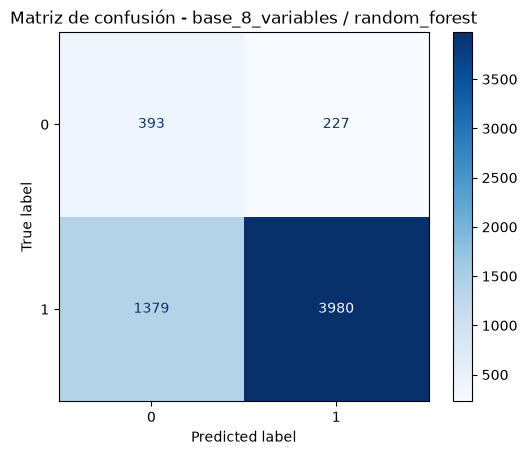

In [39]:

model_comparison = pd.DataFrame(comparison_rows).sort_values(
    "cv_roc_auc", ascending=False
).reset_index(drop=True)
metric_columns = model_comparison.select_dtypes(include=np.number).columns
comparison_display = model_comparison.copy()
comparison_display[metric_columns] = comparison_display[metric_columns].round(3)
display(comparison_display)

best_result = model_comparison.iloc[0]
best_scenario_name = best_result["escenario"]
best_model_name = best_result["modelo"]
best_features = scenario_features[best_scenario_name]
model = trained_models[(best_scenario_name, best_model_name)]
X = work[best_features].copy()
predictions = model.predict(X.iloc[testeo])
probabilities = model.predict_proba(X.iloc[testeo])[:, 1]
print(f"Mejor escenario: {best_scenario_name}")
print(f"Mejor modelo: {best_model_name}")
print(f"Variables utilizadas: {best_features}")
print(classification_report(y_test, predictions, digits=3, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap="Blues")
plt.title(f"Matriz de confusión - {best_scenario_name} / {best_model_name}")
plt.show()

In [40]:
# Comparación específica de las representaciones de edad por modelo.
SCENARIOS_EDAD = [
    "base_8_variables", "edad_cuadrado", "grupo_etario",
    "edad_y_edad_cuadrado", "edad_y_grupo_etario",
    "edad_cuadrado_y_grupo_etario", "todas_las_variables_de_edad",
]
age_comparison = model_comparison[
    model_comparison["escenario"].isin(SCENARIOS_EDAD)
].copy()
age_comparison["representacion_edad"] = age_comparison["escenario"].map({
    "base_8_variables": "EDAD",
    "edad_cuadrado": "EDAD_CUADRADO",
    "grupo_etario": "GRUPO_ETARIO",
    "edad_y_edad_cuadrado": "EDAD + EDAD_CUADRADO",
    "edad_y_grupo_etario": "EDAD + GRUPO_ETARIO",
    "edad_cuadrado_y_grupo_etario": "EDAD_CUADRADO + GRUPO_ETARIO",
    "todas_las_variables_de_edad": "EDAD + EDAD_CUADRADO + GRUPO_ETARIO",
})
best_age_by_model = (
    age_comparison.sort_values(["modelo", "cv_roc_auc"], ascending=[True, False])
    .groupby("modelo", as_index=False)
    .first()
    [["modelo", "representacion_edad", "cv_roc_auc", "test_roc_auc", "test_f1"]]
)
display(best_age_by_model.round(3))


,modelo,representacion_edad,cv_roc_auc,test_roc_auc,test_f1
0,baseline,EDAD_CUADRADO + GRUPO_ETARIO,0.500,0.500,0.945
1,random_forest,EDAD,0.758,0.766,0.832
2,regresion_logistica,EDAD,0.606,0.602,0.779
3,svm_lineal,EDAD,0.606,0.602,0.945


### Paso 4.1. Calibracion de hiperparametros

Una vez elegido el escenario de variables, se buscan configuraciones mas estables para cada modelo. `GridSearchCV` entrena cada combinacion dentro de tres particiones estratificadas y conserva el mejor pipeline.

En el Random Forest se prueban profundidad maxima, minimo de observaciones por hoja, numero de arboles y cantidad de variables candidatas por division. `max_depth` y `min_samples_leaf` son los controles principales contra arboles demasiado especificos; `n_estimators` reduce la variabilidad del ensamble.

La eleccion del bosque no usa unicamente el ROC-AUC de validacion. Se calcula `criterio_generalizacion = ROC-AUC_CV - 0.25 * brecha`, donde la brecha es la diferencia entre el ROC-AUC medio de entrenamiento y validacion. Asi se evita elegir un modelo con una ventaja minima de AUC a costa de un sobreajuste grande.

El conjunto de prueba permanece separado durante la seleccion y solo se utiliza para la medicion final.


In [41]:
from sklearn.model_selection import GridSearchCV

# Se calibra el mejor escenario inicial, no todos los escenarios otra vez.
X_selected = work[best_features].copy()
X_selected_train = X_selected.iloc[entrenamiento]
X_selected_test = X_selected.iloc[testeo]


In [42]:

variable_numerica = X_selected.select_dtypes(include=np.number).columns.tolist()
variable_categorica = X_selected.select_dtypes(exclude=np.number).columns.tolist()


In [43]:

tuning_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ]), variable_numerica),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), variable_categorica),
])



In [44]:
tuning_grids = {
    "regresion_logistica": (
        LogisticRegression(class_weight="balanced", max_iter=1000, random_state=semilla),
        {"model__C": [0.1, 0.5, 1.0, 2.0]},
    ),
    "random_forest": (
        RandomForestClassifier(class_weight="balanced", random_state=semilla, n_jobs=-1),
        {
            "model__n_estimators": [300, 500],
            "model__max_depth": [6, 10, 14],
            "model__min_samples_leaf": [10, 20, 40, 80],
            "model__max_features": ["sqrt", 0.3],
        },
    ),
    "svm_lineal": (
        CalibratedClassifierCV(
            estimator=LinearSVC(class_weight="balanced", max_iter=3000, random_state=semilla),
            method="sigmoid",
            cv=3,
            ensemble=False,
        ),
        {"model__estimator__C": [0.1, 0.5, 1.0, 2.0]},
    ),
}


In [45]:
optimizacion = StratifiedKFold(n_splits=3, shuffle=True, random_state=semilla)
optimizacion_filas = []
optimizacion_modelos = {}
optimizacion_busquedas = {}


In [46]:
for model_name, (estimator, parameter_grid) in tuning_grids.items():
    tuning_pipeline = Pipeline([
        ("preprocessor", clone(tuning_preprocessor)),
        ("model", clone(estimator)),
    ])
    search = GridSearchCV(
        estimator=tuning_pipeline,
        param_grid=parameter_grid,
        scoring="roc_auc",
        cv=optimizacion,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )
    search.fit(X_selected_train, y_train)
    optimizacion_busquedas[model_name] = search

    if model_name == "random_forest":
        cv_scores = search.cv_results_["mean_test_score"]
        train_scores = search.cv_results_["mean_train_score"]
        generalization_scores = cv_scores - 0.25 * (train_scores - cv_scores)
        selected_index = int(np.argmax(generalization_scores))
        selected_parameters = search.cv_results_["params"][selected_index]
        selected_model = clone(tuning_pipeline).set_params(**selected_parameters)
        selected_model.fit(X_selected_train, y_train)
        selected_cv_score = cv_scores[selected_index]
        selected_train_score = train_scores[selected_index]
    else:
        selected_index = search.best_index_
        selected_model = search.best_estimator_
        selected_parameters = search.best_params_
        selected_cv_score = search.best_score_
        selected_train_score = search.cv_results_["mean_train_score"][selected_index]

    tuned_predictions = selected_model.predict(X_selected_test)
    tuned_probabilities = selected_model.predict_proba(X_selected_test)[:, 1]
    optimizacion_filas.append({
        "escenario": best_scenario_name,
        "modelo": model_name,
        "tipo": "calibrado",
        "cv_roc_auc": selected_cv_score,
        "cv_roc_auc_entrenamiento": selected_train_score,
        "brecha_cv_entrenamiento": selected_train_score - selected_cv_score,
        "criterio_generalizacion": selected_cv_score - 0.25 * (selected_train_score - selected_cv_score),
        "test_roc_auc": roc_auc_score(y_test, tuned_probabilities),
        "test_f1": f1_score(y_test, tuned_predictions, zero_division=0),
        "test_precision": precision_score(y_test, tuned_predictions, zero_division=0),
        "test_recall": recall_score(y_test, tuned_predictions, zero_division=0),
        "test_accuracy": accuracy_score(y_test, tuned_predictions),
        "mejores_parametros": str(selected_parameters),
    })
    optimizacion_modelos[model_name] = selected_model


In [47]:

tuned_comparison = pd.DataFrame(optimizacion_filas).sort_values("cv_roc_auc", ascending=False).reset_index(drop=True)
display(tuned_comparison)


,escenario,modelo,tipo,cv_roc_auc,cv_roc_auc_entrenamiento,brecha_cv_entrenamiento,criterio_generalizacion,test_roc_auc,test_f1,test_precision,test_recall,test_accuracy,mejores_parametros
0,base_8_variables,random_forest,calibrado,0.757487,0.830037,0.072550,0.739350,0.773193,0.820350,0.949460,0.722150,0.716508,"{'model__max_depth': 14, 'model__max_features'..."
1,base_8_variables,regresion_logistica,calibrado,0.606511,0.610512,0.004000,0.605511,0.601965,0.779385,0.915199,0.678671,0.655628,{'model__C': 1.0}
2,base_8_variables,svm_lineal,calibrado,0.606347,0.610305,0.003958,0.605357,0.601720,0.945317,0.896304,1.000000,0.896304,{'model__estimator__C': 2.0}


In [48]:

best_tuned_result = tuned_comparison.iloc[0]
best_tuned_name = best_tuned_result["modelo"]
model = optimizacion_modelos[best_tuned_name]
trained_models[(best_scenario_name, best_tuned_name)] = model
best_model_name = f"{best_tuned_name}_calibrado"
best_result = best_tuned_result
predictions = model.predict(X_selected_test)
probabilities = model.predict_proba(X_selected_test)[:, 1]
print(f"Modelo calibrado seleccionado: {best_model_name}")
print(f"ROC-AUC CV: {best_tuned_result['cv_roc_auc']:.3f}")
print(f"ROC-AUC prueba: {best_tuned_result['test_roc_auc']:.3f}")
print(classification_report(y_test, predictions, digits=3, zero_division=0))

Modelo calibrado seleccionado: random_forest_calibrado
ROC-AUC CV: 0.757
ROC-AUC prueba: 0.773
              precision    recall  f1-score   support

           0      0.218     0.668     0.328       620
           1      0.949     0.722     0.820      5359

    accuracy                          0.717      5979
   macro avg      0.584     0.695     0.574      5979
weighted avg      0.874     0.717     0.769      5979



In [49]:
# Diagnóstico del modelo calibrado: AUC de entrenamiento frente a validación.
rf_model = optimizacion_modelos["random_forest"]
rf_train_probabilities = rf_model.predict_proba(X_selected_train)[:, 1]
rf_test_probabilities = rf_model.predict_proba(X_selected_test)[:, 1]
rf_train_auc = roc_auc_score(y_train, rf_train_probabilities)
rf_test_auc = roc_auc_score(y_test, rf_test_probabilities)
rf_parameters = rf_model.named_steps["model"].get_params()
print("Hiperparámetros RF:", {
    key: rf_parameters[key]
    for key in ["n_estimators", "max_depth", "min_samples_leaf", "max_features", "class_weight"]
})
print(f"ROC-AUC entrenamiento: {rf_train_auc:.3f}")
print(f"ROC-AUC prueba: {rf_test_auc:.3f}")
print(f"Brecha entrenamiento-prueba: {rf_train_auc - rf_test_auc:.3f}")


Hiperparámetros RF: {'n_estimators': 500, 'max_depth': 14, 'min_samples_leaf': 40, 'max_features': 'sqrt', 'class_weight': 'balanced'}
ROC-AUC entrenamiento: 0.832
ROC-AUC prueba: 0.773
Brecha entrenamiento-prueba: 0.059


In [50]:
# Ranking de configuraciones RF: se prioriza validación y se monitorea la varianza.
rf_search = optimizacion_busquedas["random_forest"]
rf_candidates = pd.DataFrame({
    "cv_roc_auc": rf_search.cv_results_["mean_test_score"],
    "train_roc_auc": rf_search.cv_results_["mean_train_score"],
    "brecha": rf_search.cv_results_["mean_train_score"] - rf_search.cv_results_["mean_test_score"],
    "parametros": rf_search.cv_results_["params"],
})
rf_candidates["criterio_generalizacion"] = (
    rf_candidates["cv_roc_auc"] - 0.25 * rf_candidates["brecha"]
)
rf_candidates = rf_candidates.sort_values("criterio_generalizacion", ascending=False)
pd.set_option("display.max_colwidth", None)
display(rf_candidates.head(10))


,cv_roc_auc,train_roc_auc,brecha,parametros,criterio_generalizacion
37,0.757487,0.830037,0.072550,"{'model__max_depth': 14, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 40, 'model__n_estimators': 500}",0.739350
36,0.757384,0.829718,0.072334,"{'model__max_depth': 14, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 40, 'model__n_estimators': 300}",0.739301
20,0.752326,0.813162,0.060836,"{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 40, 'model__n_estimators': 300}",0.737117
21,0.752173,0.813424,0.061251,"{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 40, 'model__n_estimators': 500}",0.736861
35,0.764475,0.879298,0.114823,"{'model__max_depth': 14, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 20, 'model__n_estimators': 500}",0.735769
19,0.757298,0.845063,0.087765,"{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 20, 'model__n_estimators': 500}",0.735357
34,0.764057,0.879391,0.115334,"{'model__max_depth': 14, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 20, 'model__n_estimators': 300}",0.735224
18,0.756813,0.845066,0.088253,"{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 20, 'model__n_estimators': 300}",0.734750
38,0.744945,0.788051,0.043107,"{'model__max_depth': 14, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 80, 'model__n_estimators': 300}",0.734168
39,0.744454,0.787801,0.043347,"{'model__max_depth': 14, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 80, 'model__n_estimators': 500}",0.733618


### Paso 4. Diagnostico de sesgo, varianza y capacidad de discriminacion

Las curvas de aprendizaje comparan el ROC-AUC obtenido con los datos usados para ajustar el modelo frente al ROC-AUC medido por validacion cruzada al aumentar el numero de observaciones. Una brecha grande indica varianza o overfitting; valores bajos y cercanos indican sesgo alto.

Se comparan tambien las curvas ROC sobre el mismo conjunto de prueba. El ROC-AUC mide la capacidad de ordenar pacientes con mayor probabilidad de egreso por mejoria, sin depender de un unico umbral.

El reporte `reporte_sesgo_varianza.csv` conserva la brecha final de cada clasificador. Para este proyecto, el Random Forest regularizado busca mantener la mejor discriminacion posible reduciendo la diferencia entre entrenamiento y validacion mediante `max_depth`, `min_samples_leaf`, `max_features` y un ensamble de muchos arboles.


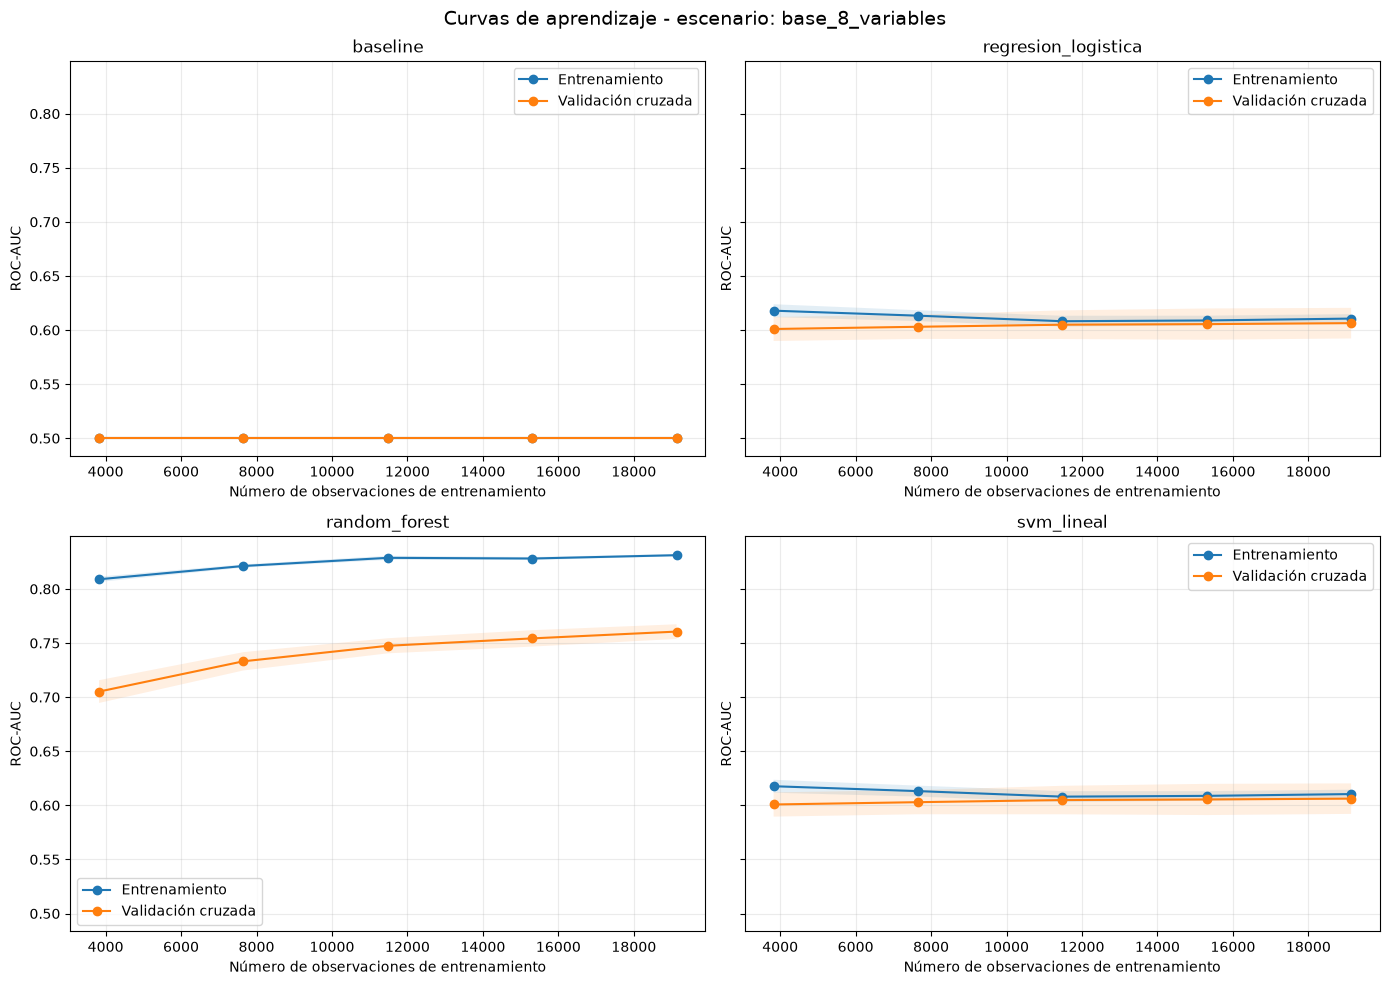

,modelo,ultimo_roc_auc_entrenamiento,ultimo_roc_auc_validacion,brecha_final_entrenamiento_validacion
0,baseline,0.500000,0.500000,0.000000
1,regresion_logistica,0.610601,0.606388,0.004213
3,svm_lineal,0.610410,0.606191,0.004219
2,random_forest,0.831208,0.760592,0.070616


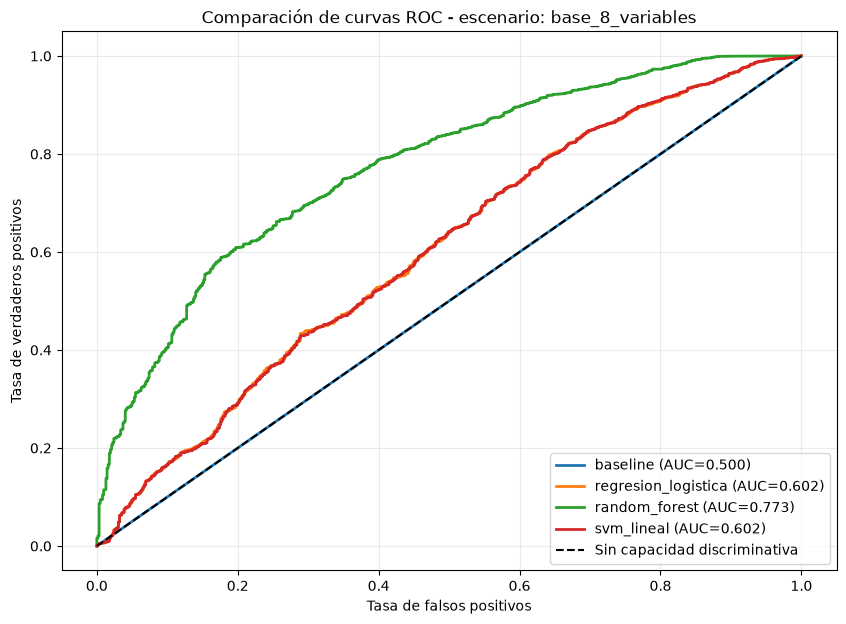

In [51]:
from sklearn.metrics import auc, roc_curve
from sklearn.model_selection import learning_curve

X_best = work[best_features].copy()
X_best_train = X_best.iloc[entrenamiento]
X_best_test = X_best.iloc[testeo]

# Curvas de aprendizaje: una gráfica por modelo en el escenario seleccionado.
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.ravel()
learning_curve_rows = []

for axis, model_name in zip(axes, models):
    candidate = trained_models[(best_scenario_name, model_name)]
    train_sizes, train_scores, validation_scores = learning_curve(
        candidate,
        X_best_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        train_sizes=np.linspace(0.20, 1.00, 5),
        n_jobs=-1,
    )
    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    validation_std = validation_scores.std(axis=1)
    learning_curve_rows.append({
        "modelo": model_name,
        "ultimo_roc_auc_entrenamiento": train_mean[-1],
        "ultimo_roc_auc_validacion": validation_mean[-1],
        "brecha_final_entrenamiento_validacion": train_mean[-1] - validation_mean[-1],
    })
    axis.plot(train_sizes, train_mean, marker="o", label="Entrenamiento")
    axis.plot(train_sizes, validation_mean, marker="o", label="Validación cruzada")
    axis.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.12)
    axis.fill_between(
        train_sizes,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.12,
    )
    axis.set_title(model_name)
    axis.set_xlabel("Número de observaciones de entrenamiento")
    axis.set_ylabel("ROC-AUC")
    axis.grid(alpha=0.25)
    axis.legend()

fig.suptitle(f"Curvas de aprendizaje - escenario: {best_scenario_name}", fontsize=14)
fig.tight_layout()
plt.show()
learning_curve_report = pd.DataFrame(learning_curve_rows)
display(learning_curve_report.sort_values("brecha_final_entrenamiento_validacion"))

# Curvas ROC: todos los modelos comparten X_best_test y y_test.
plt.figure(figsize=(10, 7))
for model_name in models:
    candidate = trained_models[(best_scenario_name, model_name)]
    test_probabilities = candidate.predict_proba(X_best_test)[:, 1]
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_probabilities)
    model_auc = auc(false_positive_rate, true_positive_rate)
    plt.plot(false_positive_rate, true_positive_rate, linewidth=2, label=f"{model_name} (AUC={model_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Sin capacidad discriminativa")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title(f"Comparación de curvas ROC - escenario: {best_scenario_name}")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.show()

learning_curve_report.to_csv(OUTPUT_DIR / "reporte_sesgo_varianza.csv", index=False, encoding="utf-8-sig")

,modelo,ultimo_roc_auc_entrenamiento,ultimo_roc_auc_validacion,brecha_final_entrenamiento_validacion
0,baseline,0.500000,0.500000,0.000000
4,baseline,0.500000,0.500000,0.000000
1,regresion_logistica,0.610601,0.606388,0.004213
5,regresion_logistica,0.610601,0.606388,0.004213
3,svm_lineal,0.610410,0.606191,0.004219
7,svm_lineal,0.610410,0.606191,0.004219
2,random_forest,0.831208,0.760592,0.070616
6,random_forest,0.831208,0.760592,0.070616


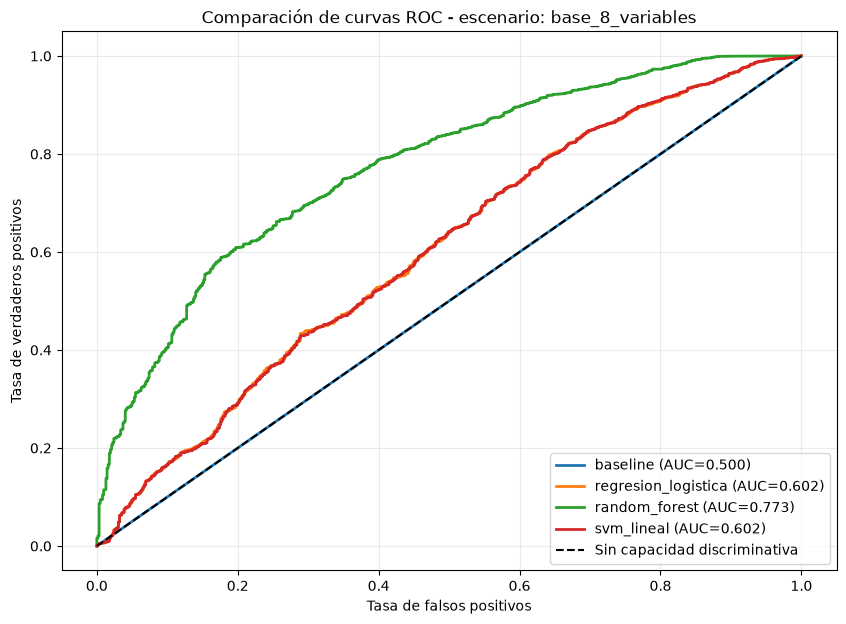

In [52]:

for axis, model_name in zip(axes, models):
    candidate = trained_models[(best_scenario_name, model_name)]
    train_sizes, train_scores, validation_scores = learning_curve(
        candidate,
        X_best_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        train_sizes=np.linspace(0.20, 1.00, 5),
        n_jobs=-1,
    )
    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    validation_std = validation_scores.std(axis=1)
    learning_curve_rows.append({
        "modelo": model_name,
        "ultimo_roc_auc_entrenamiento": train_mean[-1],
        "ultimo_roc_auc_validacion": validation_mean[-1],
        "brecha_final_entrenamiento_validacion": train_mean[-1] - validation_mean[-1],
    })
    axis.plot(train_sizes, train_mean, marker="o", label="Entrenamiento")
    axis.plot(train_sizes, validation_mean, marker="o", label="Validación cruzada")
    axis.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.12)
    axis.fill_between(
        train_sizes,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.12,
    )
    axis.set_title(model_name)
    axis.set_xlabel("Número de observaciones de entrenamiento")
    axis.set_ylabel("ROC-AUC")
    axis.grid(alpha=0.25)
    axis.legend()

fig.suptitle(f"Curvas de aprendizaje - escenario: {best_scenario_name}", fontsize=14)
fig.tight_layout()
plt.show()
learning_curve_report = pd.DataFrame(learning_curve_rows)
display(learning_curve_report.sort_values("brecha_final_entrenamiento_validacion"))

# Curvas ROC: todos los modelos comparten X_best_test y y_test.
plt.figure(figsize=(10, 7))
for model_name in models:
    candidate = trained_models[(best_scenario_name, model_name)]
    test_probabilities = candidate.predict_proba(X_best_test)[:, 1]
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_probabilities)
    model_auc = auc(false_positive_rate, true_positive_rate)
    plt.plot(false_positive_rate, true_positive_rate, linewidth=2, label=f"{model_name} (AUC={model_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Sin capacidad discriminativa")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title(f"Comparación de curvas ROC - escenario: {best_scenario_name}")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.show()

learning_curve_report.to_csv(OUTPUT_DIR / "reporte_sesgo_varianza.csv", index=False, encoding="utf-8-sig")

,porcentaje_nulos
IMC,9.680872
DIAS_ESTANCIA,0.000000
GENERO,0.000000
NIVEL_DE_GRAVEDAD,0.000000
ES_INDIGENA,0.000000
ENTIDAD,0.000000
MES,0.000000
EDAD,0.000000


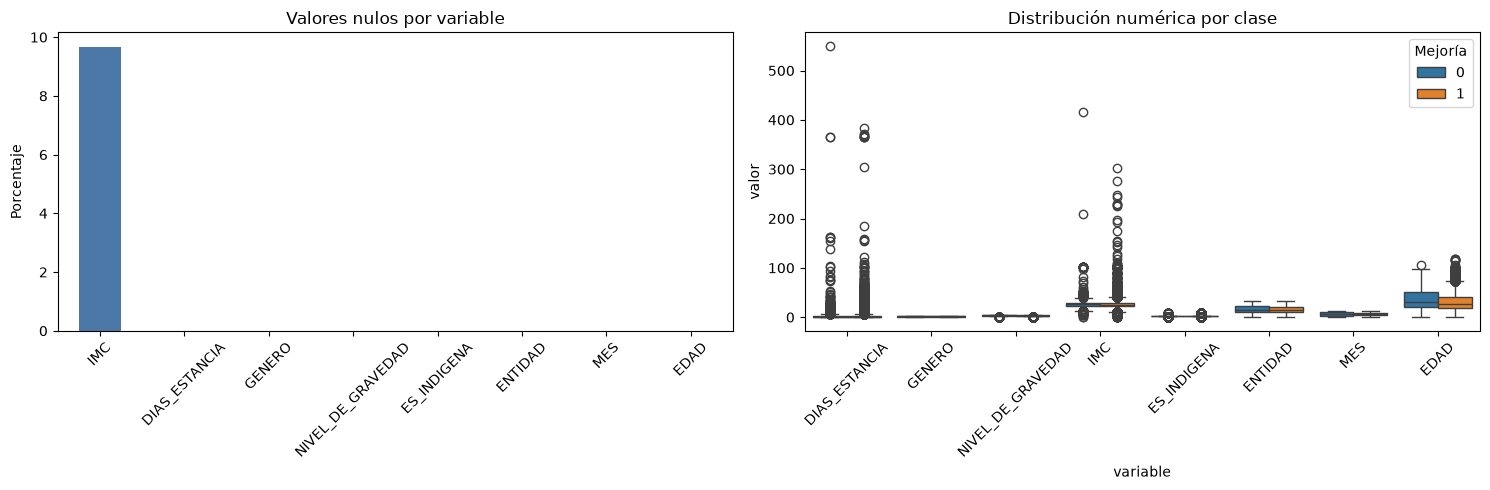

,variable,grupo,observaciones,tasa_mejoria
21,ENTIDAD,"(14.0, 16.0]",6061,0.958588
6,NIVEL_DE_GRAVEDAD,1.0,1818,0.947195
18,ES_INDIGENA,9,460,0.926087
1,DIAS_ESTANCIA,"(1.0, 2.0]",5874,0.915901
29,EDAD,"(0.999, 17.0]",6343,0.915340
11,IMC,"(0.999, 21.333]",5425,0.913180
9,NIVEL_DE_GRAVEDAD,4.0,10069,0.913000
30,EDAD,"(17.0, 23.0]",6131,0.911923
31,EDAD,"(23.0, 30.0]",5542,0.907254
8,NIVEL_DE_GRAVEDAD,3.0,13377,0.905584


,variable,importancia_media,desviacion
5,ENTIDAD,0.184023,0.009399
2,NIVEL_DE_GRAVEDAD,0.056424,0.004729
3,IMC,0.032087,0.003739
7,EDAD,0.030888,0.002993
0,DIAS_ESTANCIA,0.025220,0.002018
6,MES,0.002888,0.000842
1,GENERO,0.002553,0.000798
4,ES_INDIGENA,0.001349,0.000749


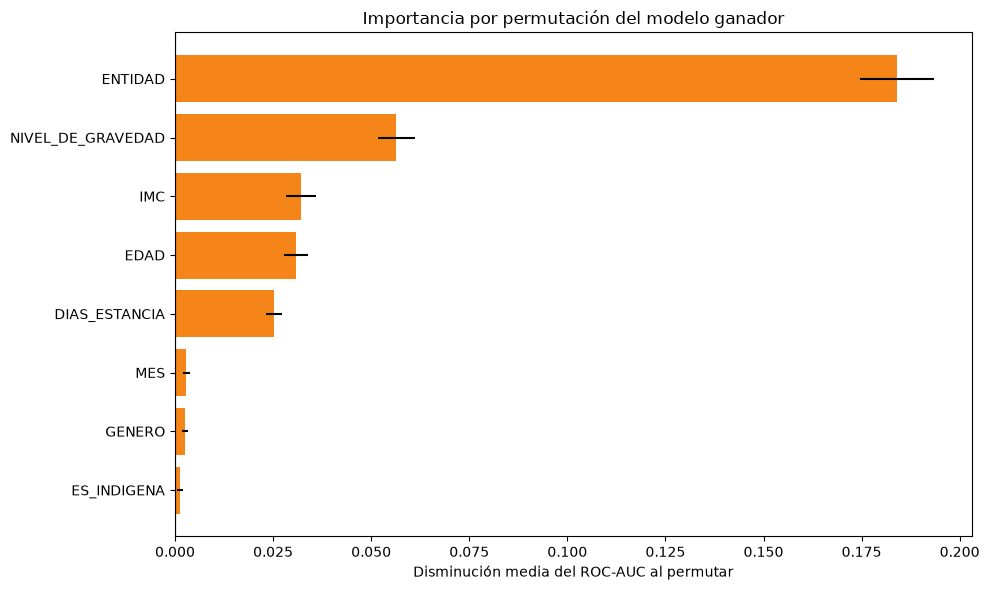

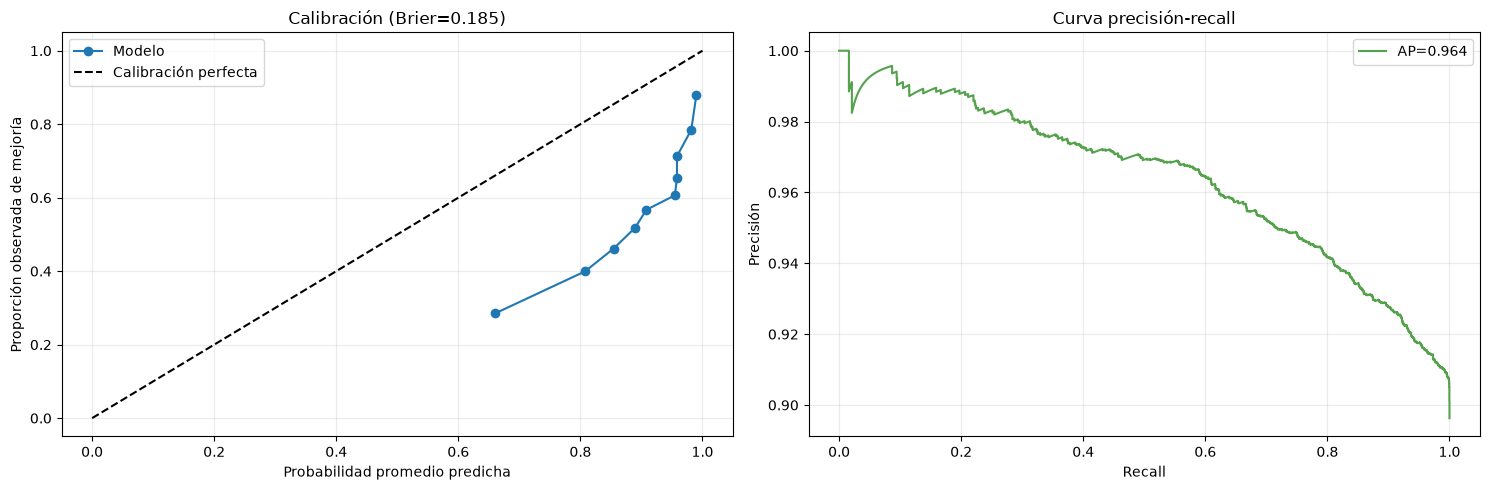

In [53]:
# 5.1 Calidad de datos, relación con el objetivo e importancia de variables.
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, brier_score_loss, precision_recall_curve

# Valores faltantes de las variables del escenario ganador.
missing_summary = (
    work[best_features].isna().mean().mul(100).sort_values(ascending=False)
    .rename("porcentaje_nulos")
    .to_frame()
)
display(missing_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
missing_summary.plot.bar(ax=axes[0], color="#4C78A8", legend=False)
axes[0].set_title("Valores nulos por variable")
axes[0].set_ylabel("Porcentaje")
axes[0].tick_params(axis="x", rotation=45)

# Distribución de variables numéricas separada por la clase objetivo.
numeric_best = work[best_features].select_dtypes(include=np.number).columns.tolist()
if numeric_best:
    long_numeric = work[numeric_best + [columna_objetivo]].melt(
        id_vars=columna_objetivo, var_name="variable", value_name="valor"
    )
    sns.boxplot(data=long_numeric, x="variable", y="valor", hue=columna_objetivo, ax=axes[1])
    axes[1].set_title("Distribución numérica por clase")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend(title="Mejoría")
else:
    axes[1].axis("off")
fig.tight_layout()
plt.show()

# Tasa observada de mejoría por categoría o por cuantiles numéricos.
target_rate_rows = []
for feature in best_features:
    series = work[feature]
    if pd.api.types.is_numeric_dtype(series) and series.nunique(dropna=True) > 8:
        groups = pd.qcut(series, q=5, duplicates="drop")
    else:
        groups = series.astype("string").fillna("FALTANTE")
    grouped = pd.DataFrame({"grupo": groups, "objetivo": y}).groupby("grupo", observed=False)
    for group_name, group in grouped:
        target_rate_rows.append({
            "variable": feature,
            "grupo": str(group_name),
            "observaciones": len(group),
            "tasa_mejoria": group["objetivo"].mean(),
        })
target_rate = pd.DataFrame(target_rate_rows)
display(target_rate.sort_values("tasa_mejoria", ascending=False).head(20))

# Importancia por permutación sobre variables originales, sin inspeccionar columnas one-hot.
permutation = permutation_importance(
    model, X_best_test, y_test, scoring="roc_auc", n_repeats=10,
    random_state=semilla, n_jobs=-1,
)
permutation_report = pd.DataFrame({
    "variable": X_best_test.columns,
    "importancia_media": permutation.importances_mean,
    "desviacion": permutation.importances_std,
}).sort_values("importancia_media", ascending=False)
display(permutation_report)

plt.figure(figsize=(10, 6))
top_permutation = permutation_report.head(15).sort_values("importancia_media")
plt.barh(top_permutation["variable"], top_permutation["importancia_media"], xerr=top_permutation["desviacion"], color="#F58518")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Disminución media del ROC-AUC al permutar")
plt.title("Importancia por permutación del modelo ganador")
plt.tight_layout()
plt.show()

# Calibración y precisión-recall: calidad de las probabilidades y desempeño en desbalance.
probability_bins, observed_rate = calibration_curve(y_test, probabilities, n_bins=10, strategy="quantile")
precision_curve, recall_curve, _ = precision_recall_curve(y_test, probabilities)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(probability_bins, observed_rate, marker="o", label="Modelo")
axes[0].plot([0, 1], [0, 1], "k--", label="Calibración perfecta")
axes[0].set_xlabel("Probabilidad promedio predicha")
axes[0].set_ylabel("Proporción observada de mejoría")
axes[0].set_title(f"Calibración (Brier={brier_score_loss(y_test, probabilities):.3f})")
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].plot(recall_curve, precision_curve, color="#54A24B", label=f"AP={average_precision_score(y_test, probabilities):.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precisión")
axes[1].set_title("Curva precisión-recall")
axes[1].legend()
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

permutation_report.to_csv(OUTPUT_DIR / "importancia_permutacion.csv", index=False, encoding="utf-8-sig")
target_rate.to_csv(OUTPUT_DIR / "tasa_mejoria_por_variable.csv", index=False, encoding="utf-8-sig")

### Paso 5. Analisis complementario y explicabilidad

Este bloque revisa si el modelo es util y si sus resultados son razonables para los datos disponibles. Primero resume faltantes del escenario ganador y muestra la distribucion de variables numericas por clase.

Luego calcula la tasa observada de mejoria por categorias o cuantiles. Esta tabla es descriptiva: ayuda a detectar patrones, pero no sustituye la validacion del modelo ni debe confundirse con causalidad.

La importancia por permutacion mide cuanto disminuye el ROC-AUC cuando se desordena una variable en el conjunto de prueba. Una disminucion mayor indica que el modelo depende mas de esa variable; un valor cercano a cero indica aporte limitado.

La curva de calibracion compara probabilidades predichas con proporciones observadas. El Brier score resume el error probabilistico. La curva precision-recall y average precision son especialmente utiles cuando la clase positiva no esta perfectamente balanceada.

Los resultados se guardan en `importancia_permutacion.csv` y `tasa_mejoria_por_variable.csv` para facilitar auditoria y comunicacion del modelo.


In [54]:
# 7. Guardado de datos, resultados y artefactos reproducibles.
clean_data = X.copy()
clean_data[columna_objetivo] = y
clean_data.to_csv(OUTPUT_DIR / "hospitales_preparados.csv", index=False, encoding="utf-8-sig")
model_comparison.to_csv(OUTPUT_DIR / "comparacion_modelos.csv", index=False, encoding="utf-8-sig")
tuned_comparison.to_csv(OUTPUT_DIR / "comparacion_modelos_calibrados.csv", index=False, encoding="utf-8-sig")
variable_report.to_csv(OUTPUT_DIR / "reporte_variables.csv", encoding="utf-8-sig")
joblib.dump(model, OUTPUT_DIR / "modelo_egreso_mejora.joblib")

base_results = model_comparison[model_comparison["escenario"] == "base_8_variables"]
additional_results = model_comparison[model_comparison["escenario"] != "base_8_variables"]
metadata = {
    "columna_objetivo": columna_objetivo,
    "positive_class": "egreso por mejoría",
    "improvement_status_code": str(Codigo_mejoria),
    "selected_scenario": best_scenario_name,
    "selected_model": best_model_name,
    "base_features": columnas_modelo,
    "selected_features": best_features,
    "escenarios": escenarios,
    "random_state": semilla,
    "rows_input": int(df.shape[0]),
    "metrics_selected_model": best_tuned_result.to_dict(),
    "best_base_cv_roc_auc": float(base_results["cv_roc_auc"].max()),
    "best_additional_cv_roc_auc": float(additional_results["cv_roc_auc"].max()),
    "calibrated_model_parameters": best_tuned_result.get("mejores_parametros"),
    "bias_variance_diagnostics": learning_curve_report.to_dict(orient="records"),
    "brier_score": float(brier_score_loss(y_test, probabilities)),
    "average_precision": float(average_precision_score(y_test, probabilities)),
}
(OUTPUT_DIR / "metadata_modelo.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2, default=str), encoding="utf-8"
)

try:
    subprocess.run([
        sys.executable, "-m", "jupyter", "nbconvert", "--to", "script",
        str(Path("Importacion y analisis.ipynb")), "--output-dir", str(OUTPUT_DIR),
        "--output", "pipeline_hospitales.py", "--log-level", "ERROR",
    ], check=True)
except (subprocess.CalledProcessError, FileNotFoundError) as error:
    print("No se pudo exportar automáticamente el notebook a .py:", error)

print("Artefactos guardados en:", OUTPUT_DIR.resolve())
for artifact in sorted(OUTPUT_DIR.iterdir()):
    print("-", artifact.name)


Artefactos guardados en: C:\Users\Luis Alberto\Documents\GitHub\Proyecto Gentera\Notebooks\Outputs
- __pycache__
- api_fastapi.py
- comparacion_modelos.csv
- comparacion_modelos_calibrados.csv
- entrenar_modelo.py
- hospitales_preparados.csv
- importancia_permutacion.csv
- metadata_modelo.json
- modelo_egreso_mejora.joblib
- modelo_utils.py
- pipeline_hospitales.py.py
- predecir_nuevos.py
- README.md
- reporte_sesgo_varianza.csv
- reporte_variables.csv
- requirements.txt
- tasa_mejoria_por_variable.csv


### Paso 6. Guardado y reproducibilidad

La ultima celda concentra los artefactos que permiten repetir o consumir el resultado fuera del notebook. `hospitales_preparados.csv` conserva la base procesada; `comparacion_modelos.csv` y `comparacion_modelos_calibrados.csv` guardan las metricas de las alternativas evaluadas.

`reporte_variables.csv`, `reporte_sesgo_varianza.csv`, `importancia_permutacion.csv` y `tasa_mejoria_por_variable.csv` documentan calidad, generalizacion, relevancia y comportamiento descriptivo de las variables.

`modelo_egreso_mejora.joblib` contiene el pipeline completo: imputacion, transformaciones categoricas, escalamiento y Random Forest. Por eso puede cargarse directamente desde `predecir_nuevos.py` o `api_fastapi.py` sin repetir manualmente el preprocesamiento.

`metadata_modelo.json` registra objetivo, codigo positivo, variables, hiperparametros, filas procesadas y metricas. El notebook se ubica en la raiz, mientras sus entradas y reportes permanecen organizados dentro de `Notebooks/Inputs` y `Notebooks/Outputs`.
